<a href="https://colab.research.google.com/github/Chirag240105/Machine_Learning/blob/main/Loan_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 2: Upload kaggle.json API key
from google.colab import files
files.upload()

# STEP 3: Setup Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d architsharma01/loan-approval-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
License(s): MIT
100% 80.6k/80.6k [00:00<00:00, 59.2MB/s]



In [3]:
!unzip loan-approval-prediction-dataset.zip


Archive:  loan-approval-prediction-dataset.zip
  inflating: loan_approval_dataset.csv  


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    f1_score,
    precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

import seaborn as sns

In [6]:
df = pd.read_csv('loan_approval_dataset.csv')

In [7]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [9]:
print(df.isnull().sum())
df.describe()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop('loan_id', axis=1)

one for columns Other for strips of columns

In [28]:
df.columns = df.columns.str.strip()

In [14]:
for col in df.select_dtypes(include="object").columns: # removing white spaces
  df[col] = df[col].str.strip()

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Encode Categorical **Data**

In [15]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
  df[col] = le.fit_transform(df[col])

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


# `*Correlation HeatMap*`

Thing is all the values given in heat map are between 0 and 1 in magnitude hence

positve -> strong co relation
zero -> no co relation
negative -> strong negative co relation



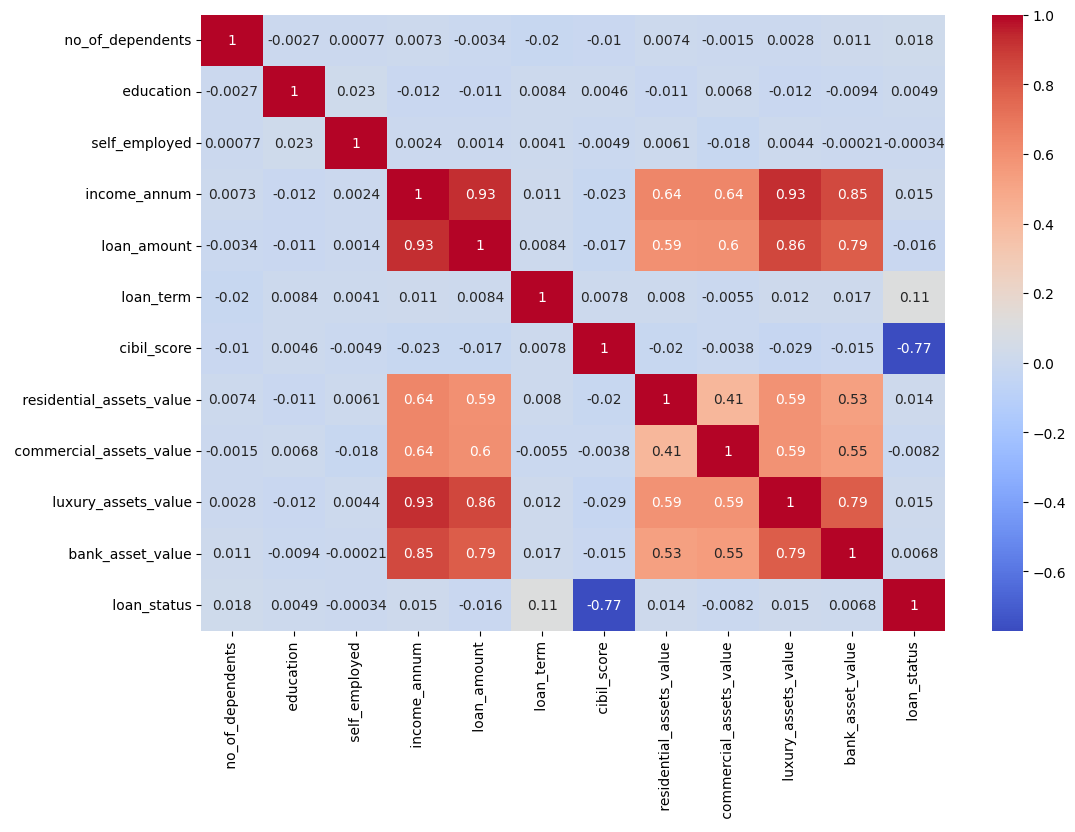

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:

X = df.drop("loan_status", axis=1)
y = df['loan_status']
X.head()
y.head()

,loan_status
0,0
1,1
2,1
3,1
4,1


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
    )
#making sure both splits are a perfect miniature replica of your original data.

# `Feature Scaling`

So that the large value and small value don't make model confuse make all values b/w -3 and +3

In [36]:
scaler = StandardScaler()
x_trained_scaler = scaler.fit_transform(X_train)
x_test_scaler = scaler.transform(X_test)


In [37]:
logi_model = LogisticRegression(max_iter=1000)
logi_model.fit(x_trained_scaler, y_train)
logi_pred= logi_model.predict(x_test_scaler)
logi_prob = logi_model.predict_proba(x_test_scaler)[:, 1]
# For Logistic Regression, feature scaling is absolutely mandatory.
# Because it relies on matrix multiplication and gradient descent to
# find the best weights for your features, huge numbers
#  (like a $5,000,000 income) will completely wreck the math if
#   they aren't scaled down to match smaller numbers (like 2 dependents).

In [38]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


In [40]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)
# In machine learning classification,
# Log Loss (short for Logarithmic Loss, also known as Cross-Entropy Loss)
#  is a metric that evaluates how good your model's probabilities are,
#  rather than just its final "Approved" or "Rejected" guesses.

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [41]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
    print("Model:", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-" * 60)

In [42]:
evaluate_model("Logistic Regression", y_test, logi_pred, logi_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

Model: Logistic Regression
Accuracy: 0.9227166276346604
Precision: 0.9158576051779935
Recall: 0.8761609907120743
F1 Score: 0.8955696202531646
ROC-AUC: 0.9745092208753855

Confusion Matrix:
 [[505  26]
 [ 40 283]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       531
           1       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854

------------------------------------------------------------
Model: Random Forest
Accuracy: 0.9836065573770492
Precision: 0.9904761904761905
Recall: 0.9659442724458205
F1 Score: 0.9780564263322884
ROC-AUC: 0.997956423128276

Confusion Matrix:
 [[528   3]
 [ 11 312]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97 

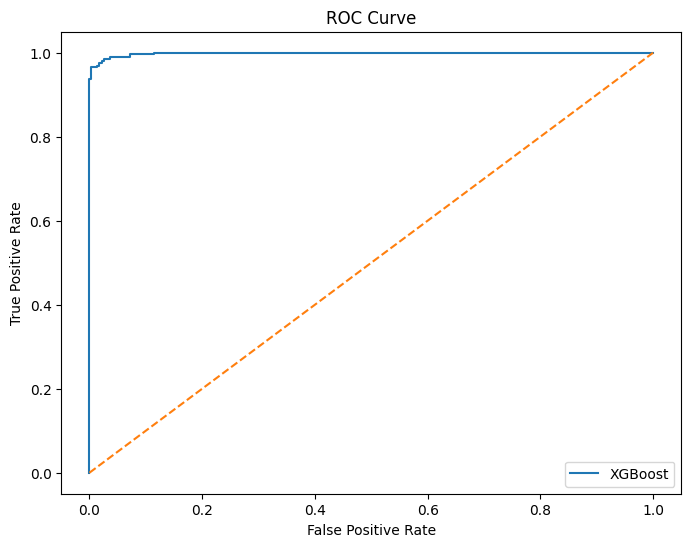

In [43]:
fpr, tpr, threshold = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

                     Feature  Importance
6                cibil_score    0.801152
5                  loan_term    0.064358
4                loan_amount    0.030672
3               income_annum    0.020317
9        luxury_assets_value    0.019399
8    commercial_assets_value    0.018403
7   residential_assets_value    0.017593
10          bank_asset_value    0.015068
0           no_of_dependents    0.007783
2              self_employed    0.002866
1                  education    0.002389


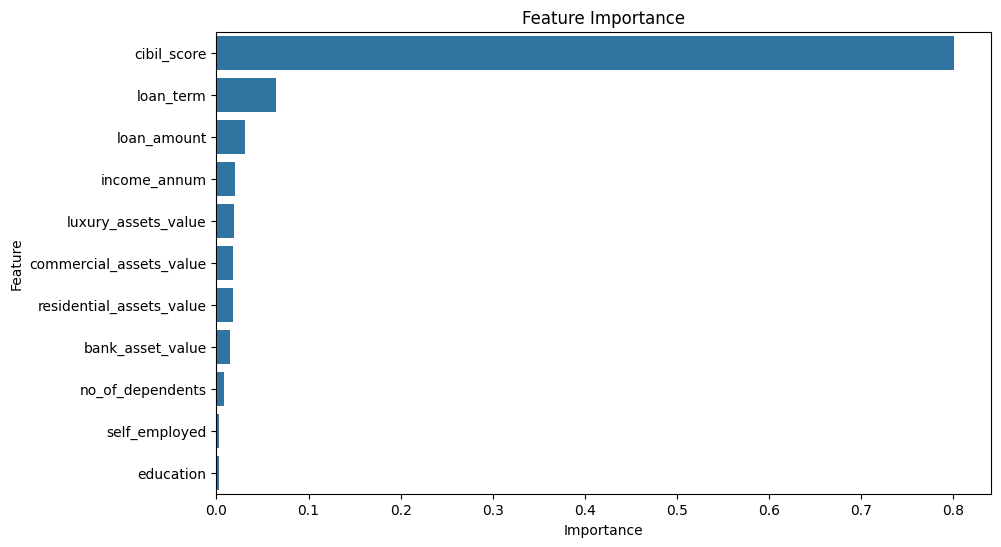

In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

In [48]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
0.997796625626995


In [49]:

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

evaluate_model("Tuned XGBoost", y_test, best_pred, best_prob)

Model: Tuned XGBoost
Accuracy: 0.9824355971896955
Precision: 0.9842767295597484
Recall: 0.9690402476780186
F1 Score: 0.9765990639625585
ROC-AUC: 0.9987581116300223

Confusion Matrix:
 [[526   5]
 [ 10 313]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.98      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

------------------------------------------------------------
